# Emotion Recognition con Vision Transformer (ViT-Small)
## Proyecto Final Inteligencia Artificial 
### Sofía Jaramillo Chavarría - Juan Esteban Toro Caraballo

- Datasets y preprocesamiento
- Arquitectura ViT con clasificador adaptado
- Entrenamiento con mixed precision + scheduler
- Evaluación exhaustiva (métricas, matriz de confusión, ROC-AUC)
 **Attention map visualization** — qué regiones faciales activa el ViT por emoción

## 0. Setup

In [1]:
 !pip install -r /kaggle/input/datasets/sofiajch07/requirements/requirements.txt

In [2]:
import os, json, random, time, warnings
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dispositivo
device = (
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('mps') if torch.backends.mps.is_available() else
    torch.device('cpu')
)
print(f'Dispositivo : {device}')
if device.type == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# Detectar rutas de AffectNet en Kaggle
AFFECT_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'affectnet' in root and 'archive (3)' in dirs:
        AFFECT_ROOT = os.path.join(root, 'archive (3)')
        break
if AFFECT_ROOT is None:
    possible = "/kaggle/input/datasets/sofiajch07/affectnet/archive (3)"
    if os.path.exists(possible):
        AFFECT_ROOT = possible

if AFFECT_ROOT is None:
    raise FileNotFoundError("No se pudo encontrar la carpeta 'archive (3)' de AffectNet en /kaggle/input")

print(f"Ruta AffectNet: {AFFECT_ROOT}")

# Rutas de Train y Test
PATHS = {
    'affectnet_train': os.path.join(AFFECT_ROOT, 'Train'),
    'affectnet_test': os.path.join(AFFECT_ROOT, 'Test'),
}
for name, path in PATHS.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encuentra {name}: {path}")
    print(f"{name}: {path}")

# Directorio de salida
OUT = Path('./vit_outputs')
OUT.mkdir(exist_ok=True)
(OUT / 'checkpoints').mkdir(exist_ok=True)

# Constantes
EMOTION_LABELS = {0:'Happy', 1:'Surprise', 2:'Sad', 3:'Anger',
                  4:'Disgust', 5:'Fear', 6:'Neutral'}
NUM_CLASSES = 7
IMG_SIZE = 224
AFFECT_MAP = {'happy':0, 'surprise':1, 'sad':2, 'anger':3,
              'disgust':4, 'fear':5, 'neutral':6}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tiff', '.bmp'}
COLORS = ['#4CAF50', '#FF9800', '#2196F3', '#F44336',
          '#9C27B0', '#00BCD4', '#607D8B']

# Hiperparametros
HPARAMS = {
    'model_name': 'vit_small_patch16_224',
    'pretrained': True,
    'batch_size': 32,
    'num_epochs': 20,
    'lr_head': 1e-3,
    'lr_backbone': 1e-5,
    'weight_decay': 0.05,
    'label_smoothing': 0.1,
    'warmup_epochs': 5,
    'patience': 7,
    'val_split': 0.15,
    'num_workers': 2,
    'freeze_epochs': 3,
}

print('\nHiperparametros:')
for k, v in HPARAMS.items():
    print(f'  {k:<18}: {v}')

Dispositivo : cuda
GPU         : Tesla T4
VRAM        : 15.6 GB
Ruta AffectNet: /kaggle/input/datasets/sofiajch07/affectnet/archive (3)
affectnet_train: /kaggle/input/datasets/sofiajch07/affectnet/archive (3)/Train
affectnet_test: /kaggle/input/datasets/sofiajch07/affectnet/archive (3)/Test

Hiperparametros:
  model_name        : vit_small_patch16_224
  pretrained        : True
  batch_size        : 32
  num_epochs        : 20
  lr_head           : 0.001
  lr_backbone       : 1e-05
  weight_decay      : 0.05
  label_smoothing   : 0.1
  warmup_epochs     : 5
  patience          : 7
  val_split         : 0.15
  num_workers       : 2
  freeze_epochs     : 3


## 1. Dataset

In [3]:
# Dataset class for AffectNet
class AffectNetDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.transform = transform
        self.samples = []
        if not os.path.exists(img_dir):
            raise FileNotFoundError(img_dir)
        for folder in sorted(os.listdir(img_dir)):
            fp = os.path.join(img_dir, folder)
            if os.path.isdir(fp) and folder.lower() in AFFECT_MAP:
                label = AFFECT_MAP[folder.lower()]
                for f in os.listdir(fp):
                    if Path(f).suffix.lower() in IMG_EXTS:
                        self.samples.append((os.path.join(fp, f), label))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Transformaciones de la imagen (data augmentation)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08)),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Cargar dataset
print('\nCargando AffectNet...')
train_full = AffectNetDataset(PATHS['affectnet_train'], transform=train_tf)
test_ds = AffectNetDataset(PATHS['affectnet_test'], transform=val_tf)

print(f"  AffectNet train total: {len(train_full):,} imagenes")
print(f"  AffectNet test total: {len(test_ds):,} imagenes")

# Division train/val
val_size = int(HPARAMS['val_split'] * len(train_full))
train_size = len(train_full) - val_size
train_ds, val_ds = random_split(train_full, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

print(f"\nSplit final:")
print(f"  Train : {len(train_ds):,}")
print(f"  Val   : {len(val_ds):,}")
print(f"  Test  : {len(test_ds):,}")


Cargando AffectNet...
  AffectNet train total: 14,549 imagenes
  AffectNet test total: 13,206 imagenes

Split final:
  Train : 12,367
  Val   : 2,182
  Test  : 13,206


In [4]:
# WeightedRandomSampler
train_labels_full = [label for _, label in train_full.samples]
class_counts = np.bincount(train_labels_full, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / (class_counts + 1e-6)

train_indices = train_ds.indices
train_subset_labels = [train_labels_full[i] for i in train_indices]
sample_weights = [class_weights[l] for l in train_subset_labels]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_subset_labels), replacement=True)

# DataLoaders
BS = HPARAMS['batch_size']
NW = HPARAMS['num_workers']
train_loader = DataLoader(train_ds, batch_size=BS, sampler=sampler, num_workers=NW, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=True)

print("\nDataLoaders creados con WeightedRandomSampler")


DataLoaders creados con WeightedRandomSampler


## 2. Modelo - ViT Small con clasificador de emociones
**Estrategia de fine-tuning por fases:**
- **Fase 1** (épocas 1-3): solo el clasificador — el backbone está congelado. Permite que el head converja antes de propagar gradientes al backbone.
- **Fase 2** (épocas 4+): backbone descongelado con lr muy baja (1e-5). El backbone ya aprendió features generales de ImageNet; solo necesita adaptación leve.

In [5]:
# Modelo ViTEmotionClassifier
class ViTEmotionClassifier(nn.Module):
    """
    ViT-Small pre-entrenado en ImageNet-21k con clasificador
    adaptado para 7 emociones.

    Arquitectura del head:
      [CLS token features (384-d)]
        → LayerNorm
        → Linear(384, 256) + GELU + Dropout(0.3)
        → Linear(256, 7)

    La capa de LayerNorm extra antes del head estabiliza el
    entrenamiento cuando se usa label smoothing.
    """
    def __init__(self, model_name='vit_small_patch16_224', num_classes=7, pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
    def get_attention_maps(self, x):
        attn_weights = []
        def hook_fn(module, input, output):
            attn_weights.append(output)
        last_block = self.backbone.blocks[-1]
        handle = last_block.attn.attn_drop.register_forward_hook(hook_fn)
        with torch.no_grad():
            logits = self.forward(x)
        handle.remove()
        return logits, attn_weights[0] if attn_weights else None

# Instanciar modelo
model = ViTEmotionClassifier(
    model_name=HPARAMS['model_name'],
    num_classes=NUM_CLASSES,
    pretrained=HPARAMS['pretrained']
).to(device)
model.freeze_backbone()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParametros totales: {total_params:,}')
print(f'Entrenables (fase 1): {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')
print(f'Feature dim: {model.backbone.num_features}')
print(f'Modelo: {HPARAMS["model_name"]}')


Parametros totales: 21,766,791
Entrenables (fase 1): 101,127 (0.5%)
Feature dim: 384
Modelo: vit_small_patch16_224


## 3. Entrenamiento

In [6]:
# Loss, optimizer, scheduler
# Entropia cruzada (suavizado de etiquetas), AdamW (tasas de aprendizajes diferenciadas)
criterion = nn.CrossEntropyLoss(label_smoothing=HPARAMS['label_smoothing'])

def build_optimizer(model, phase):
    if phase == 1:
        return optim.AdamW(
            model.classifier.parameters(),
            lr=HPARAMS['lr_head'],
            weight_decay=HPARAMS['weight_decay']
        )
    else:
        return optim.AdamW([
            {'params': model.backbone.parameters(), 'lr': HPARAMS['lr_backbone']},
            {'params': model.classifier.parameters(), 'lr': HPARAMS['lr_head']},
        ], weight_decay=HPARAMS['weight_decay'])

optimizer = build_optimizer(model, phase=1)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-7)

use_amp = device.type == 'cuda'
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f'Optimizer: AdamW  |  lr_head={HPARAMS["lr_head"]}  lr_backbone={HPARAMS["lr_backbone"]}')
print(f'Scheduler: CosineAnnealingWarmRestarts T_0=10')
print(f'Loss: CrossEntropyLoss(label_smoothing={HPARAMS["label_smoothing"]})')
print(f'AMP: {use_amp}')

# Entrenamiento
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc = 0.0
epochs_no_impr = 0
best_model_path = str(OUT / 'checkpoints' / 'best_vit_emotion.pth')

def run_epoch(loader, training=True):
    # forward, backward, gradiente, actualización de pesos
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

print('\nIniciando entrenamiento...')
print(f'Epocas freeze (solo head): {HPARAMS["freeze_epochs"]}')
print(f'Epocas totales: {HPARAMS["num_epochs"]}')
print('-' * 65)
print(f'{"Epoch":>6} {"T.Loss":>8} {"T.Acc":>7} {"V.Loss":>8} {"V.Acc":>7}  Nota')
print('-' * 65)

# Bucle de entrenamiento
for epoch in range(1, HPARAMS['num_epochs'] + 1):
    if epoch == HPARAMS['freeze_epochs'] + 1:
        model.unfreeze_backbone()
        optimizer = build_optimizer(model, phase=2)
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-7)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  -> Backbone descongelado. Parametros entrenables: {trainable:,}')
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader, training=False)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    nota = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        epochs_no_impr = 0
        torch.save(model.state_dict(), best_model_path)
        nota = '* best'
    else:
        epochs_no_impr += 1
        if epochs_no_impr >= HPARAMS['patience']:
            print(f'  Early stopping en epoca {epoch}. Mejor val_acc: {best_val_acc:.2f}%')
            break
    elapsed = time.time() - t0
    print(f'{epoch:>6} {tr_loss:>8.4f} {tr_acc:>6.2f}% {vl_loss:>8.4f} {vl_acc:>6.2f}%  {nota}  ({elapsed:.0f}s)')

with open(OUT / 'history.json', 'w') as f:
    json.dump(history, f)
print(f'\nMejor val accuracy: {best_val_acc:.2f}%')

Optimizer: AdamW  |  lr_head=0.001  lr_backbone=1e-05
Scheduler: CosineAnnealingWarmRestarts T_0=10
Loss: CrossEntropyLoss(label_smoothing=0.1)
AMP: True

Iniciando entrenamiento...
Epocas freeze (solo head): 3
Epocas totales: 20
-----------------------------------------------------------------
 Epoch   T.Loss   T.Acc   V.Loss   V.Acc  Nota
-----------------------------------------------------------------
     1   1.4888  45.78%   1.2971  55.68%  * best  (54s)
     2   1.3509  52.94%   1.2711  57.75%  * best  (48s)
     3   1.3169  55.11%   1.2465  57.75%    (49s)
  -> Backbone descongelado. Parametros entrenables: 21,766,791
     4   1.2583  59.13%   1.1531  62.92%  * best  (53s)
     5   1.1364  65.95%   1.0927  66.91%  * best  (52s)
     6   1.0638  70.28%   1.1054  66.91%    (52s)
     7   1.0064  73.94%   1.0570  69.11%  * best  (55s)
     8   0.9506  76.12%   1.1007  66.96%    (53s)
     9   0.8995  79.40%   1.0902  68.88%    (55s)
    10   0.8722  80.66%   1.0579  70.85%  * best

## 4. Curvas de entrenamiento

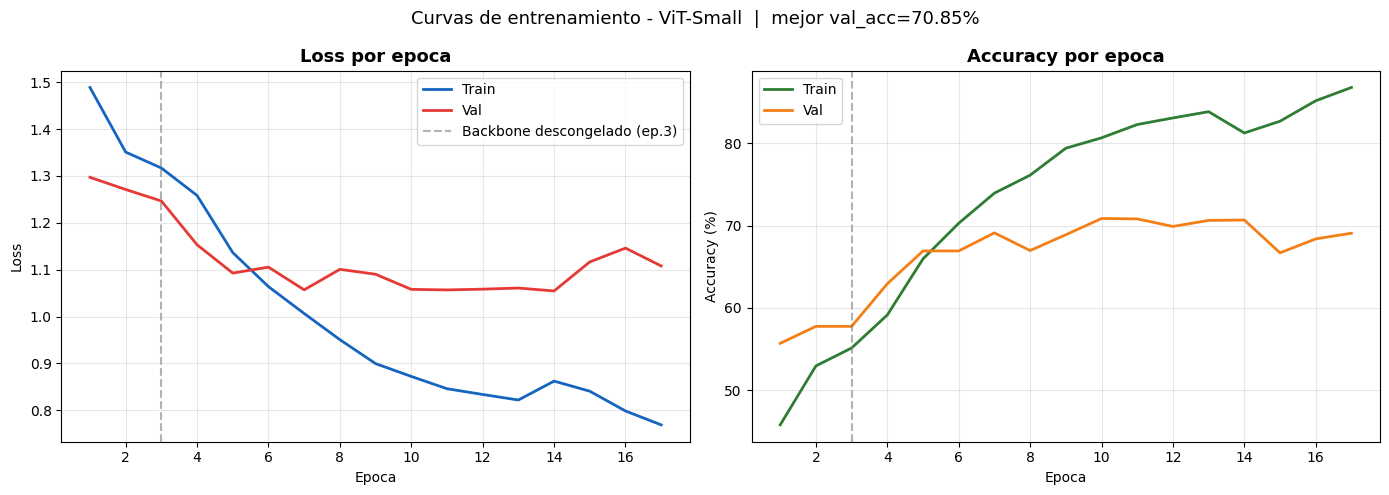

In [7]:
# Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
freeze_line = HPARAMS['freeze_epochs']
ax1.plot(epochs_range, history['train_loss'], label='Train', color='#1565C0', lw=2)
ax1.plot(epochs_range, history['val_loss'], label='Val', color='#E53935', lw=2)
ax1.axvline(freeze_line, color='gray', linestyle='--', alpha=0.6, label=f'Backbone descongelado (ep.{freeze_line})')
ax1.set_title('Loss por epoca', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_range, history['train_acc'], label='Train', color='#2E7D32', lw=2)
ax2.plot(epochs_range, history['val_acc'], label='Val', color='#F57F17', lw=2)
ax2.axvline(freeze_line, color='gray', linestyle='--', alpha=0.6)
ax2.set_title('Accuracy por epoca', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle(f'Curvas de entrenamiento - ViT-Small  |  mejor val_acc={best_val_acc:.2f}%', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluación en test set

Modelo cargado desde: vit_outputs/checkpoints/best_vit_emotion.pth


Evaluando test set: 100%|██████████| 413/413 [00:43<00:00,  9.44it/s]



  Test Accuracy  : 68.19%
  Precision (mac): 65.05%
  Recall (mac)   : 64.58%
  F1-Score (mac) : 64.01%
  ROC-AUC (mac)  : 0.9133

Classification Report:
              precision    recall  f1-score   support

       Happy     0.8900    0.9216    0.9055      2704
    Surprise     0.5378    0.4375    0.4825      1920
         Sad     0.5520    0.7670    0.6420      1584
       Anger     0.6762    0.4657    0.5515      1718
     Disgust     0.5543    0.4904    0.5204      1248
        Fear     0.5897    0.5114    0.5478      1664
     Neutral     0.7535    0.9269    0.8313      2368

    accuracy                         0.6819     13206
   macro avg     0.6505    0.6458    0.6401     13206
weighted avg     0.6764    0.6819    0.6716     13206



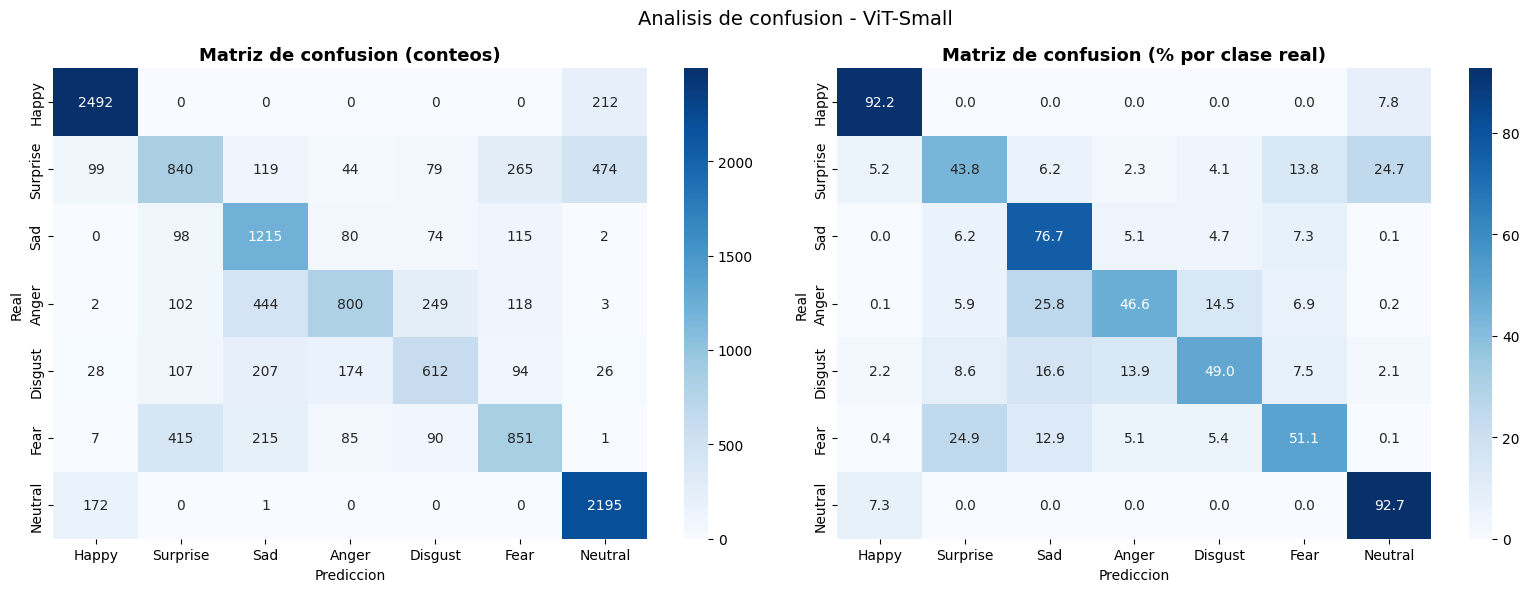


Pares de confusion mas frecuentes (excluyendo diagonal):
  Surprise   -> Neutral     (474 casos)
  Anger      -> Sad         (444 casos)
  Fear       -> Surprise    (415 casos)
  Surprise   -> Fear        (265 casos)
  Anger      -> Disgust     (249 casos)
  Fear       -> Sad         (215 casos)
  Happy      -> Neutral     (212 casos)
  Disgust    -> Sad         (207 casos)


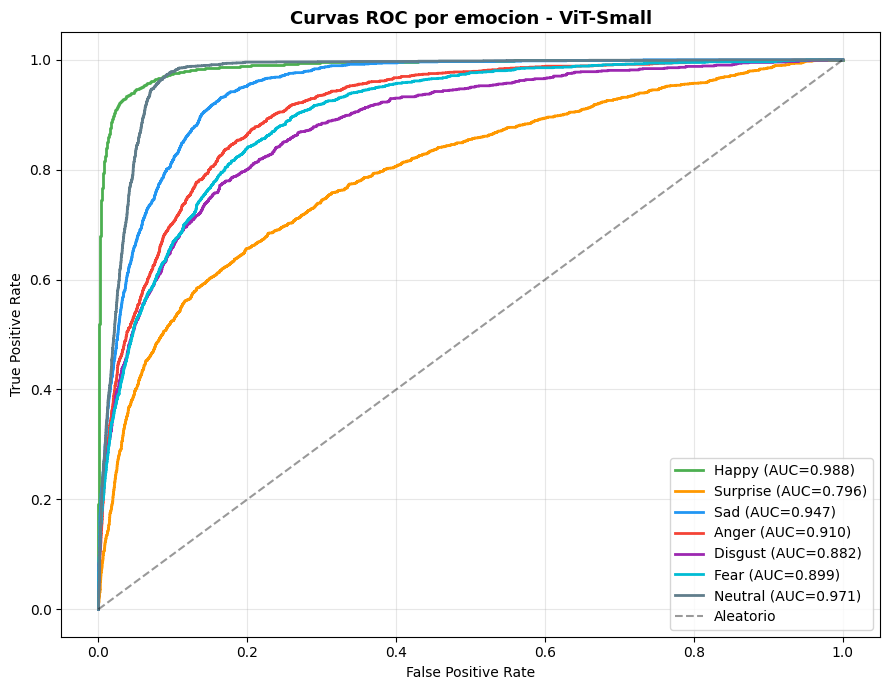

In [8]:
# Evaluacion en test set
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print(f'Modelo cargado desde: {best_model_path}')

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Evaluando test set'):
        imgs = imgs.to(device)
        out = model(imgs)
        prob = F.softmax(out, dim=1)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(prob.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

acc = 100 * (y_true == y_pred).mean()
precision = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
recall = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100
roc_auc = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

print(f'\n{"=" * 45}')
print(f'  Test Accuracy  : {acc:.2f}%')
print(f'  Precision (mac): {precision:.2f}%')
print(f'  Recall (mac)   : {recall:.2f}%')
print(f'  F1-Score (mac) : {f1:.2f}%')
print(f'  ROC-AUC (mac)  : {roc_auc:.4f}')
print(f'{"=" * 45}')

print('\nClassification Report:')
print(classification_report(
    y_true, y_pred,
    target_names=[EMOTION_LABELS[i] for i in range(NUM_CLASSES)],
    digits=4
))

# Matriz de confusion, precisión, recall, F1
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels_list = [EMOTION_LABELS[i] for i in range(NUM_CLASSES)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_list, yticklabels=labels_list, ax=ax1)
ax1.set_title('Matriz de confusion (conteos)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Prediccion'); ax1.set_ylabel('Real')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', xticklabels=labels_list, yticklabels=labels_list, ax=ax2)
ax2.set_title('Matriz de confusion (% por clase real)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Prediccion'); ax2.set_ylabel('Real')
plt.suptitle('Analisis de confusion - ViT-Small', fontsize=14)
plt.tight_layout()
plt.savefig(OUT / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPares de confusion mas frecuentes (excluyendo diagonal):')
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
pairs = [(cm_no_diag[i,j], EMOTION_LABELS[i], EMOTION_LABELS[j])
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j]
for count, real, pred in sorted(pairs, reverse=True)[:8]:
    print(f'  {real:<10} -> {pred:<10}  ({count} casos)')

# Curvas ROC por clase
fig, ax = plt.subplots(figsize=(9, 7))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[i], lw=2, label=f'{EMOTION_LABELS[i]} (AUC={roc_i:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Aleatorio')
ax.set_title('Curvas ROC por emocion - ViT-Small', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Attention Maps
Esta es la contribución más diferenciadora del trabajo respecto a una CNN. El mecanismo de self-attention permite visualizar qué tokens (parches) de la imagen el modelo pesa más al clasificar cada emoción.

Primera pasada: buscando ejemplos correctamente clasificados...
Encontrados 7/7 ejemplos correctamente clasificados


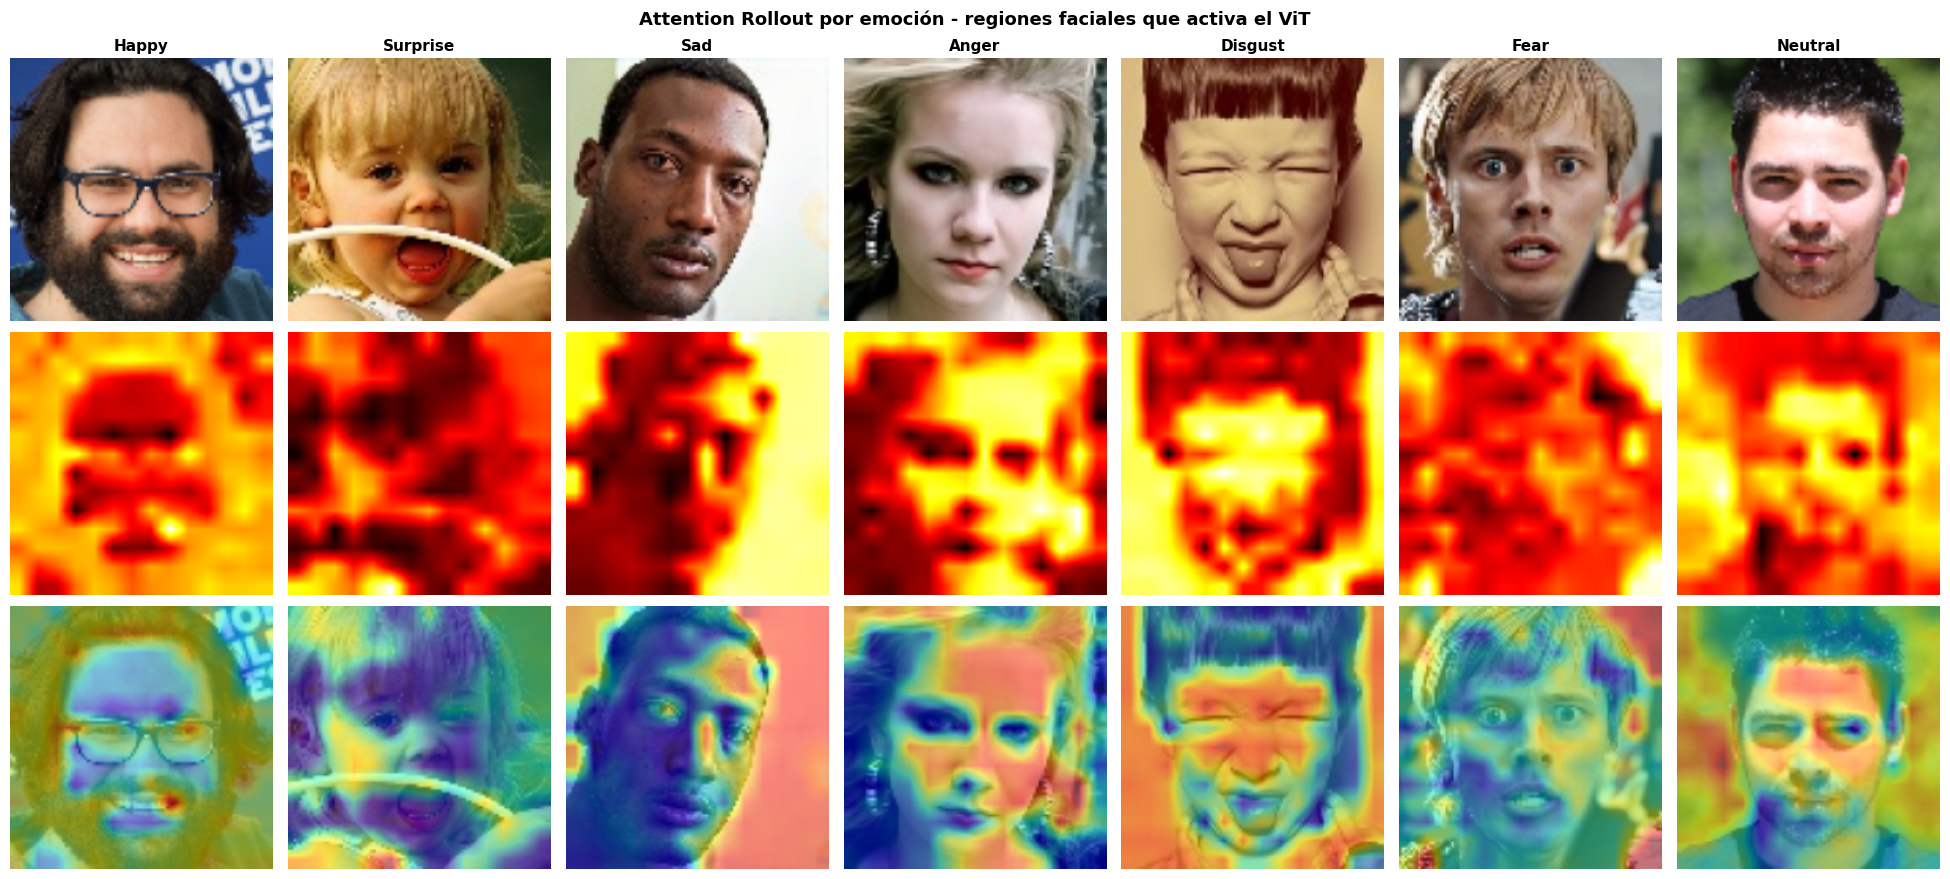

In [21]:
# Atención: Recrear el modelo y generar attention maps

from PIL import Image as PILImage
import matplotlib.cm as cm_mpl
import numpy as np
import torch

# Recrear el modelo (sin output_attentions)
model_attn = timm.create_model(
    HPARAMS['model_name'],
    pretrained=False,
    num_classes=NUM_CLASSES
).to(device)

# Cargar los pesos entrenados
state_dict = torch.load(best_model_path, map_location=device)
model_attn.load_state_dict(state_dict, strict=False)
model_attn.eval()

# Función para extraer mapas de atención
def get_attention_rollout_v2(model, img_tensor):
    """
    Captura las matrices de atención de todas las capas Attention.
    Soporta attn_mask e is_causal.
    """
    attention_weights = []
    original_forwards = {}

    def make_new_forward(module):
        """Crea un forward que guarda los pesos de atención."""
        # Guardar el forward original
        original_forward = module.forward
        
        def new_forward(x, attn_mask=None, is_causal=False):
            B, N, C = x.shape
            qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, module.head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv.unbind(0)
            q, k = module.q_norm(q), module.k_norm(k)
            q = q * module.scale

            attn = (q @ k.transpose(-2, -1))
            if attn_mask is not None:
                attn = attn + attn_mask
            if is_causal:
                causal_mask = torch.triu(torch.ones(N, N, device=x.device) * float('-inf'), diagonal=1)
                attn = attn + causal_mask
            attn = attn.softmax(dim=-1)

            # GUARDAR los pesos de atención
            attention_weights.append(attn.detach())

            attn = module.attn_drop(attn)
            x = attn @ v
            x = x.transpose(1, 2).reshape(B, N, C)
            x = module.proj(x)
            x = module.proj_drop(x)
            return x
        
        return new_forward, original_forward

    for name, module in model.named_modules():
        if name.endswith('.attn') and type(module).__name__ == 'Attention':
            new_forward, original_forward = make_new_forward(module)
            original_forwards[name] = original_forward
            module.forward = new_forward

    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(device))

    for name, module in model.named_modules():
        if name in original_forwards:
            module.forward = original_forwards[name]

    if len(attention_weights) == 0:
        raise RuntimeError("No se capturaron pesos de atención. Revisa la estructura del modelo.")

    result = torch.eye(attention_weights[0].size(-1)).to(device)
    for attn in attention_weights:
        attn_avg = attn.mean(dim=1).squeeze(0)
        attn_aug = attn_avg + torch.eye(attn_avg.size(0)).to(device)
        attn_aug = attn_aug / attn_aug.sum(dim=-1, keepdim=True)
        result = torch.mm(attn_aug, result)

    mask = result[0, 1:]
    num_patches = int(mask.shape[0] ** 0.5)
    mask = mask.reshape(num_patches, num_patches).cpu().numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask

def denormalize(tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Seleccionar ejemplos (garantiza 1 por clase, incluso si falla)
model_attn.eval()
emotion_samples = {}

# Primera pasada: preferir aciertos
print('Primera pasada: buscando ejemplos correctamente clasificados...')
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev = imgs.to(device)
        preds = model_attn(imgs_dev).argmax(dim=1).cpu()
        for i, (label, pred) in enumerate(zip(labels, preds)):
            l = label.item()
            if l not in emotion_samples and l == pred.item():
                emotion_samples[l] = imgs[i].clone()
        if len(emotion_samples) == NUM_CLASSES:
            break

print(f'Encontrados {len(emotion_samples)}/{NUM_CLASSES} ejemplos correctamente clasificados')

# Segunda pasada: si faltan emociones, tomar cualquier imagen de esa clase
missing = set(range(NUM_CLASSES)) - set(emotion_samples.keys())
if missing:
    print(f'Faltan: {[EMOTION_LABELS[m] for m in missing]} → buscando en el dataset completo...')
    with torch.no_grad():
        for imgs, labels in test_loader:
            for i, label in enumerate(labels):
                l = label.item()
                if l in missing and l not in emotion_samples:
                    emotion_samples[l] = imgs[i].clone()
                    print(f'  Agregado: {EMOTION_LABELS[l]}')
                    missing.discard(l)
            if not missing:
                break

# Visualización
if len(emotion_samples) > 0:
    n_emotions = len(emotion_samples)
    fig, axes = plt.subplots(3, n_emotions, figsize=(n_emotions * 2.8, 9))
    if n_emotions == 1:
        axes = np.expand_dims(axes, axis=1)  # asegurar 2D

    for col, (eid, img_t) in enumerate(sorted(emotion_samples.items())):
        img_vis = denormalize(img_t).permute(1, 2, 0).numpy()
        attn_map = get_attention_rollout_v2(model_attn, img_t)

        attn_resized = np.array(
            PILImage.fromarray((attn_map * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), PILImage.BILINEAR
            )
        ) / 255.0
        heatmap = cm_mpl.jet(attn_resized)[:, :, :3]
        overlay = 0.5 * img_vis + 0.5 * heatmap
        overlay = np.clip(overlay, 0, 1)

        axes[0, col].imshow(img_vis)
        axes[0, col].set_title(EMOTION_LABELS[eid], fontsize=11, fontweight='bold')
        axes[0, col].axis('off')
        axes[1, col].imshow(attn_resized, cmap='hot')
        axes[1, col].axis('off')
        axes[2, col].imshow(overlay)
        axes[2, col].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=11, rotation=0, labelpad=60, va='center')
    axes[1, 0].set_ylabel('Attention map', fontsize=11, rotation=0, labelpad=60, va='center')
    axes[2, 0].set_ylabel('Overlay', fontsize=11, rotation=0, labelpad=60, va='center')

    plt.suptitle('Attention Rollout por emoción - regiones faciales que activa el ViT', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT / 'attention_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ninguna imagen. Omitiendo attention maps.")

## 7. Métricas

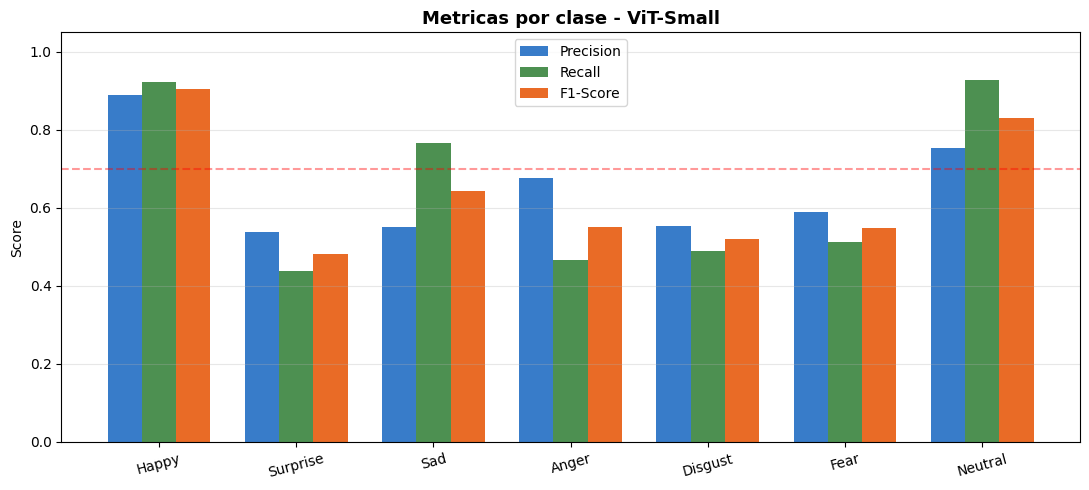

  RESUMEN FINAL DEL EXPERIMENTO
  Modelo        : vit_small_patch16_224
  Pretrained    : ImageNet-21k
  Datasets      : AffectNet (solo)
  Train images  : 12,367
  Test images   : 13,206
  Epocas        : 17
  --- Metricas test ---
  Accuracy      : 68.19%
  F1-Score (mac): 64.01%
  ROC-AUC (mac) : 0.9133
  --- Clases mas dificiles ---
  Surprise  : F1=0.482
  Disgust   : F1=0.520
  Fear      : F1=0.548

Metricas guardadas en: vit_outputs/final_metrics.json
Outputs guardados en: vit_outputs


In [22]:
# Metricas por clase y resumen final
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
per_class_prec = precision_score(y_true, y_pred, average=None, zero_division=0)
per_class_rec = recall_score(y_true, y_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(NUM_CLASSES)
width = 0.25
ax.bar(x - width, per_class_prec, width, label='Precision', color='#1565C0', alpha=0.85)
ax.bar(x, per_class_rec, width, label='Recall', color='#2E7D32', alpha=0.85)
ax.bar(x + width, per_class_f1, width, label='F1-Score', color='#E65100', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([EMOTION_LABELS[i] for i in range(NUM_CLASSES)], rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Metricas por clase - ViT-Small', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.7, color='red', linestyle='--', alpha=0.4, label='Umbral 0.7')
plt.tight_layout()
plt.savefig(OUT / 'per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 55)
print('  RESUMEN FINAL DEL EXPERIMENTO')
print('=' * 55)
print(f'  Modelo        : {HPARAMS["model_name"]}')
print(f'  Pretrained    : ImageNet-21k')
print(f'  Datasets      : AffectNet (solo)')
print(f'  Train images  : {len(train_ds):,}')
print(f'  Test images   : {len(test_ds):,}')
print(f'  Epocas        : {len(history["train_loss"])}')
print('  --- Metricas test ---')
print(f'  Accuracy      : {acc:.2f}%')
print(f'  F1-Score (mac): {f1:.2f}%')
print(f'  ROC-AUC (mac) : {roc_auc:.4f}')
print('  --- Clases mas dificiles ---')
worst = sorted(range(NUM_CLASSES), key=lambda i: per_class_f1[i])[:3]
for i in worst:
    print(f'  {EMOTION_LABELS[i]:<10}: F1={per_class_f1[i]:.3f}')
print('=' * 55)

metrics = {
    'model': HPARAMS['model_name'],
    'accuracy': round(acc, 4),
    'precision_macro': round(precision, 4),
    'recall_macro': round(recall, 4),
    'f1_macro': round(f1, 4),
    'roc_auc_macro': round(roc_auc, 4),
    'per_class_f1': {EMOTION_LABELS[i]: round(per_class_f1[i], 4) for i in range(NUM_CLASSES)},
    'hparams': HPARAMS
}
with open(OUT / 'final_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'\nMetricas guardadas en: {OUT}/final_metrics.json')
print('Outputs guardados en:', str(OUT))